# Lightpanda vs Google Chrome Benchmark Report

Interactive report notebook for comparing browser engine performance over local Express runs (to eliminate network latency issues). Both Lightpanda and Chrome are launched as fresh Docker containers per iteration, ensuring a clean state and making cold-start times directly comparable.

**Why Docker for both engines?**  
Lightpanda has no native Windows support — on Windows the only option is WSL2 or Docker (see [Lightpanda installation docs](https://lightpanda.io/docs/open-source/installation)). To keep the comparison fair (same runtime environment, same isolation overhead), Chrome also runs in Docker rather than natively. This ensures cold-start times reflect container launch costs equally for both engines.

**Benchmark context**
- Workload: 100 iterations against local Express server (network latency minimized)
- Host: Macbook Pro
- CPU: M3 Max (16 cores)
- RAM: 48 GB

## 1. Environment Setup and Notebook Parameters

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot and table defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
pd.options.display.float_format = '{:,.3f}'.format

# Color palette
colors = {'Lightpanda': '#1f77b4', 'Google Chrome': '#ff7f0e'}

# Parameters
csv_path = Path('../../../lp-simple-scraper/results/10_local_launch/11_benchmark_macbook_m3max_express_100runs_isolated_launch.csv')
artifacts_dir = Path('report_artifacts')
fig_dir = artifacts_dir / 'figures'
table_dir = artifacts_dir / 'tables'

for folder in [artifacts_dir, fig_dir, table_dir]:
    folder.mkdir(parents=True, exist_ok=True)

rolling_window = 10
expected_rows = 200
expected_iterations = 100
expected_engines = ['Lightpanda', 'Google Chrome']

print(f'CSV path: {csv_path.resolve()}')
print(f'Artifacts dir: {artifacts_dir.resolve()}')

CSV path: /Users/clemenszellinger/CLEMENS/1_Studium/Master_MC/2_Semester/CD_ContinuousDelivery/cdas-lightpanda/lp-simple-scraper/results/10_local_launch/11_benchmark_macbook_m3max_express_100runs_isolated_launch.csv
Artifacts dir: /Users/clemenszellinger/CLEMENS/1_Studium/Master_MC/2_Semester/CD_ContinuousDelivery/cdas-lightpanda/docs/benchmarks/10_local_launch/report_artifacts


## 2. Load CSV

In [2]:
df = pd.read_csv(csv_path, sep=';', decimal=',')
df.columns = [c.strip() for c in df.columns]

numeric_cols = ['ColdStartTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Iteration'] = pd.to_numeric(df['Iteration'], errors='coerce').astype('Int64')

# Normalize engine labels
engine_map = {
    'lightpanda': 'Lightpanda',
    'google chrome': 'Google Chrome',
    'chrome': 'Google Chrome'
}
df['Engine'] = (
    df['Engine']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(engine_map)
    .fillna(df['Engine'])
)

df = df.sort_values(['Iteration', 'Engine']).reset_index(drop=True)
df.head()

,Iteration,Engine,ColdStartTimeMs,NavigationTimeMs,TotalTimeMs,MemoryUsageMB
0,1,Google Chrome,321.110,204.940,663.870,132.800
1,1,Lightpanda,213.180,188.450,411.070,17.990
2,2,Google Chrome,377.300,181.590,586.050,82.200
3,2,Lightpanda,178.300,162.950,348.090,6.020
4,3,Google Chrome,352.590,169.750,540.790,82.270


## 3. Data Validation and Quality Checks

In [3]:
row_count = len(df)
iteration_count = df['Iteration'].nunique()
engines_found = sorted(df['Engine'].dropna().unique().tolist())

pair_count = df.groupby('Iteration')['Engine'].nunique()
missing_rows = df[df[numeric_cols + ['Iteration']].isna().any(axis=1)]
duplicates = df.duplicated(subset=['Iteration', 'Engine'], keep=False)
nonpositive = (df[numeric_cols] <= 0).any(axis=1)

print('Rows:', row_count)
print('Unique iterations:', iteration_count)
print('Engines found:', engines_found)
print('Pair completeness (min/max engines per iteration):', pair_count.min(), pair_count.max())
print('Rows with missing values:', len(missing_rows))
print('Duplicate Iteration+Engine rows:', int(duplicates.sum()))
print('Rows with nonpositive timing/memory values:', int(nonpositive.sum()))

assert row_count == expected_rows, f'Expected {expected_rows} rows, got {row_count}'
assert iteration_count == expected_iterations, f'Expected {expected_iterations} iterations, got {iteration_count}'
assert set(expected_engines).issubset(set(engines_found)), 'Expected engines not fully present'
assert pair_count.eq(2).all(), 'Each iteration must have exactly two engine rows'
assert len(missing_rows) == 0, 'Missing values found in required columns'
assert int(duplicates.sum()) == 0, 'Duplicate Iteration+Engine rows found'
assert int(nonpositive.sum()) == 0, 'Nonpositive values found in metric columns'

print('Validation checks passed.')

Rows: 200
Unique iterations: 100
Engines found: ['Google Chrome', 'Lightpanda']
Pair completeness (min/max engines per iteration): 2 2
Rows with missing values: 0
Duplicate Iteration+Engine rows: 0
Rows with nonpositive timing/memory values: 0
Validation checks passed.


## 4. Feature Engineering for Benchmark Metrics

In [4]:
df['ColdStartShare'] = df['ColdStartTimeMs'] / df['TotalTimeMs']
df['NavigationShare'] = df['NavigationTimeMs'] / df['TotalTimeMs']

pivot = df.pivot(index='Iteration', columns='Engine', values=numeric_cols)
pivot.columns = [f'{metric}_{engine}' for metric, engine in pivot.columns]
pivot = pivot.reset_index()

pivot['TotalSpeedup'] = pivot['TotalTimeMs_Google Chrome'] / pivot['TotalTimeMs_Lightpanda']
pivot['ColdStartSpeedup'] = pivot['ColdStartTimeMs_Google Chrome'] / pivot['ColdStartTimeMs_Lightpanda']
pivot['NavigationSpeedup'] = pivot['NavigationTimeMs_Google Chrome'] / pivot['NavigationTimeMs_Lightpanda']
pivot['MemoryRatio'] = pivot['MemoryUsageMB_Google Chrome'] / pivot['MemoryUsageMB_Lightpanda']

pivot['TotalDeltaMs'] = pivot['TotalTimeMs_Google Chrome'] - pivot['TotalTimeMs_Lightpanda']
pivot['MemoryDeltaMB'] = pivot['MemoryUsageMB_Google Chrome'] - pivot['MemoryUsageMB_Lightpanda']

pivot.head()

,Iteration,ColdStartTimeMs_Google Chrome,ColdStartTimeMs_Lightpanda,NavigationTimeMs_Google Chrome,NavigationTimeMs_Lightpanda,TotalTimeMs_Google Chrome,TotalTimeMs_Lightpanda,MemoryUsageMB_Google Chrome,MemoryUsageMB_Lightpanda,TotalSpeedup,ColdStartSpeedup,NavigationSpeedup,MemoryRatio,TotalDeltaMs,MemoryDeltaMB
0,1,321.110,213.180,204.940,188.450,663.870,411.070,132.800,17.990,1.615,1.506,1.088,7.382,252.800,114.810
1,2,377.300,178.300,181.590,162.950,586.050,348.090,82.200,6.020,1.684,2.116,1.114,13.654,237.960,76.180
2,3,352.590,154.950,169.750,164.910,540.790,323.630,82.270,7.360,1.671,2.276,1.029,11.178,217.160,74.910
3,4,325.480,173.250,170.800,162.420,512.740,339.370,81.070,7.130,1.511,1.879,1.052,11.370,173.370,73.940
4,5,301.520,162.460,169.940,160.750,488.080,326.840,82.040,7.360,1.493,1.856,1.057,11.147,161.240,74.680


## 5. Metrics Overview

Aggregated mean, median, min, and max for each metric across all iterations, plus a visual side-by-side comparison per engine.

,ColdStartTimeMs_Mean,ColdStartTimeMs_Median,ColdStartTimeMs_Min,ColdStartTimeMs_Max,NavigationTimeMs_Mean,NavigationTimeMs_Median,NavigationTimeMs_Min,NavigationTimeMs_Max,TotalTimeMs_Mean,TotalTimeMs_Median,TotalTimeMs_Min,TotalTimeMs_Max,MemoryUsageMB_Mean,MemoryUsageMB_Median,MemoryUsageMB_Min,MemoryUsageMB_Max
Engine,,,,,,,,,,,,,,,,
Google Chrome,308.300,304.550,289.020,377.300,172.520,172.340,165.480,204.940,498.840,493.280,476.080,663.870,82.690,82.360,81.020,132.800
Lightpanda,155.910,151.720,132.260,310.680,163.490,162.990,158.570,193.780,323.590,317.880,299.090,508.930,7.390,7.330,5.790,17.990


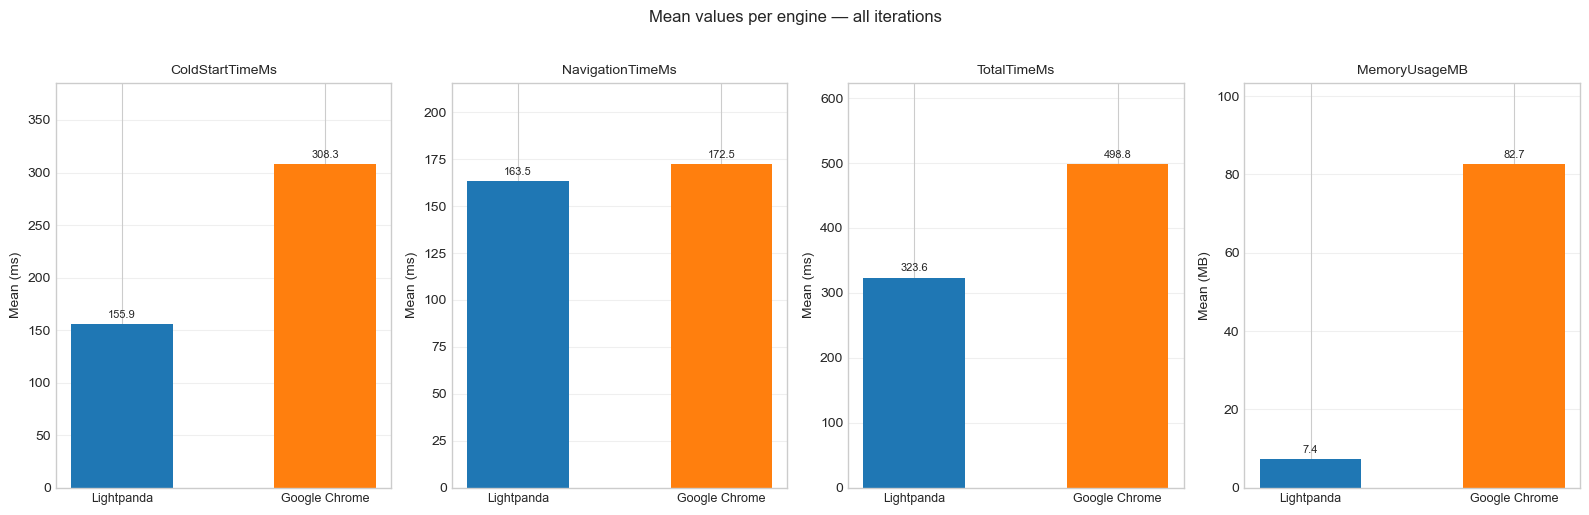

In [5]:
overview_metrics = ['ColdStartTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']
overview = df.groupby('Engine')[overview_metrics].agg(['mean', 'median', 'min', 'max']).round(2)
overview.columns = [f'{m}_{s.capitalize()}' for m, s in overview.columns]
display(overview)

fig, axes = plt.subplots(1, len(overview_metrics), figsize=(16, 5))
for ax, metric in zip(axes, overview_metrics):
    vals = [df[df['Engine'] == e][metric].mean() for e in expected_engines]
    bars = ax.bar(expected_engines, vals, color=[colors[e] for e in expected_engines], width=0.5)
    ax.set_title(metric, fontsize=10)
    ax.set_ylabel('Mean (ms)' if 'Time' in metric else 'Mean (MB)')
    ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=3)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Mean values per engine — all iterations', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6. Engine-Level Summary Statistics

Compute central tendency, dispersion, tail percentiles, and relative deltas.

In [6]:
metrics = ['ColdStartTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']

def p90(x):
    return np.percentile(x, 90)

def p95(x):
    return np.percentile(x, 95)

def p99(x):
    return np.percentile(x, 99)

summary = (
    df.groupby('Engine')[metrics]
    .agg(['mean', 'median', 'min', 'max', 'std', p90, p95, p99])
)
summary.columns = [f'{m}_{s}' for m, s in summary.columns]

for metric in metrics:
    summary[f'{metric}_cv'] = summary[f'{metric}_std'] / summary[f'{metric}_mean']

summary = summary.sort_index()
summary

# Relative delta table using Delta% = (A - B) / B * 100
def delta_percent(a, b):
    return (a - b) / b * 100

lp = summary.loc['Lightpanda']
ch = summary.loc['Google Chrome']

delta_rows = []
for metric in metrics:
    delta_rows.append({
        'Metric': metric,
        'MeanDeltaPct_Chrome_vs_Lightpanda': delta_percent(ch[f'{metric}_mean'], lp[f'{metric}_mean']),
        'MedianDeltaPct_Chrome_vs_Lightpanda': delta_percent(ch[f'{metric}_median'], lp[f'{metric}_median'])
    })

delta_table = pd.DataFrame(delta_rows)
delta_table

,Metric,MeanDeltaPct_Chrome_vs_Lightpanda,MedianDeltaPct_Chrome_vs_Lightpanda
0,ColdStartTimeMs,97.736,100.735
1,NavigationTimeMs,5.528,5.737
2,TotalTimeMs,54.159,55.180
3,MemoryUsageMB,"1,019.094","1,023.670"


## 7. Iteration Charts

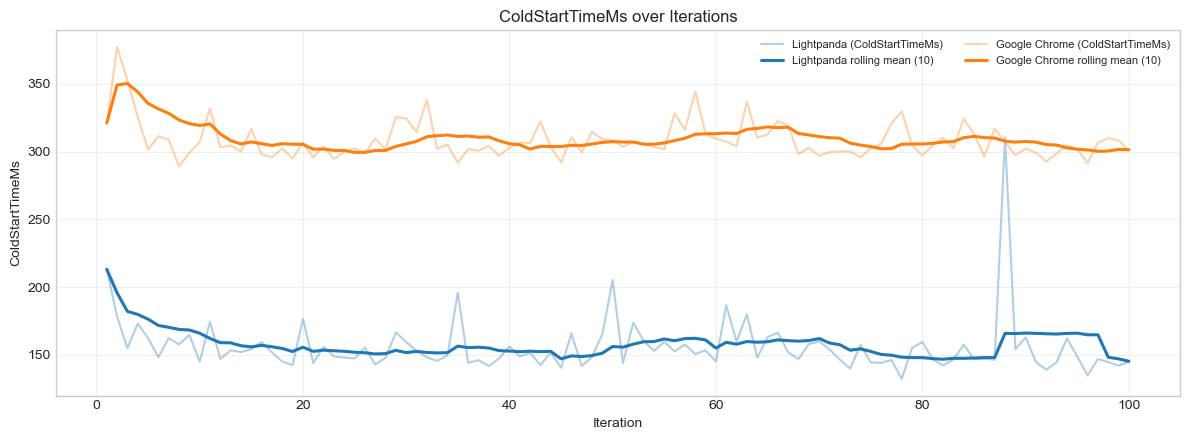

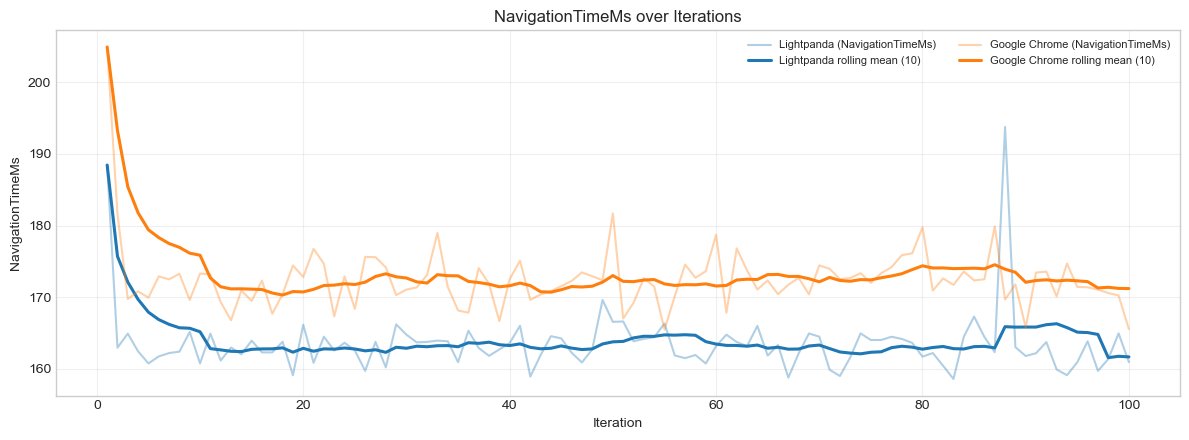

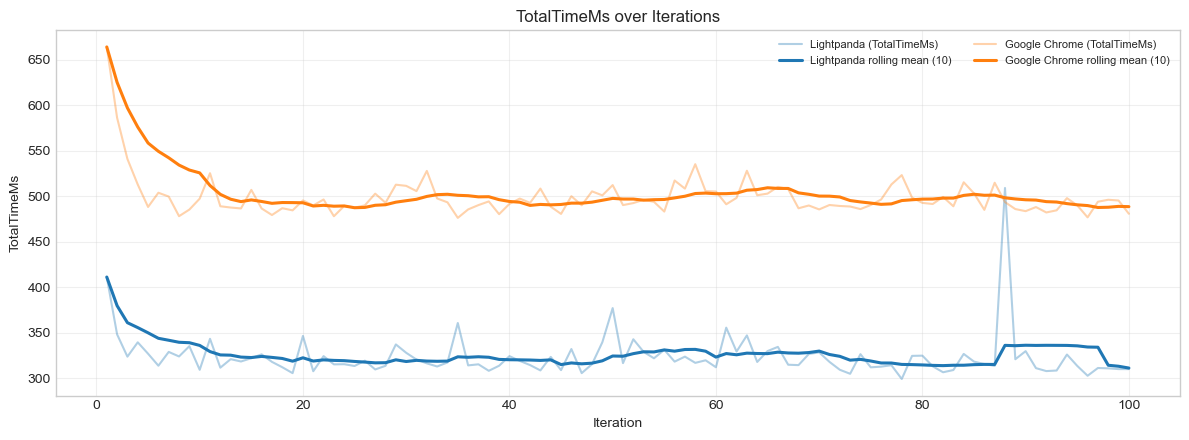

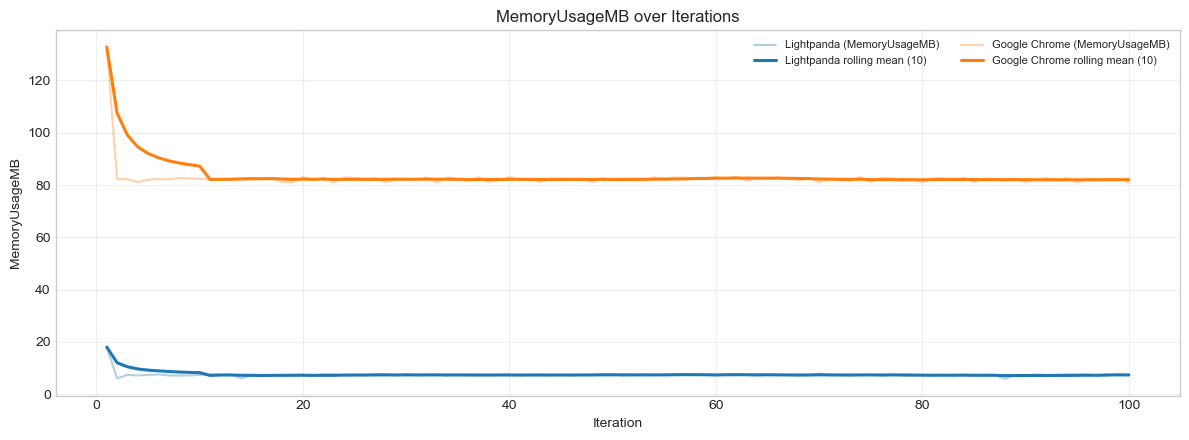

In [7]:
trend_metrics = ['ColdStartTimeMs', 'NavigationTimeMs', 'TotalTimeMs', 'MemoryUsageMB']

for metric in trend_metrics:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for engine in expected_engines:
        d = df[df['Engine'] == engine].sort_values('Iteration')
        ax.plot(d['Iteration'], d[metric], alpha=0.35, color=colors[engine], label=f'{engine} ({metric})')
        roll = d[metric].rolling(rolling_window, min_periods=1).mean()
        ax.plot(d['Iteration'], roll, linewidth=2.2, color=colors[engine], label=f'{engine} rolling mean ({rolling_window})')
    ax.set_title(f'{metric} over Iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(metric)
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Distribution Charts for Latency and Resource Usage

Boxplots to inspect spread and tail behavior.

/var/folders/7c/d5p267zs7kq4dvvhwh58v3kr0000gn/T/ipykernel_9171/2776573236.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=expected_engines, showfliers=True)


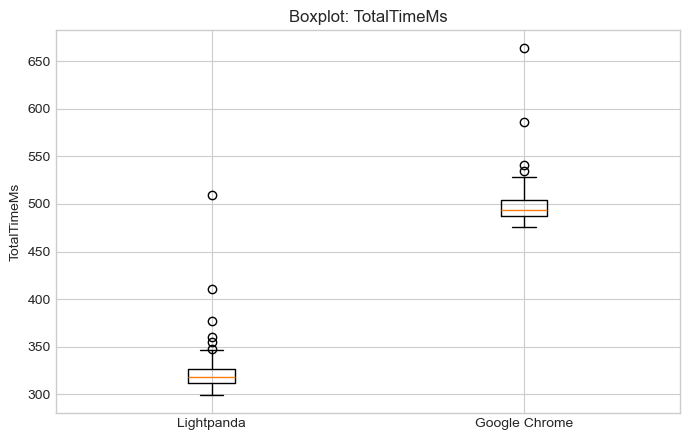

/var/folders/7c/d5p267zs7kq4dvvhwh58v3kr0000gn/T/ipykernel_9171/2776573236.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=expected_engines, showfliers=True)


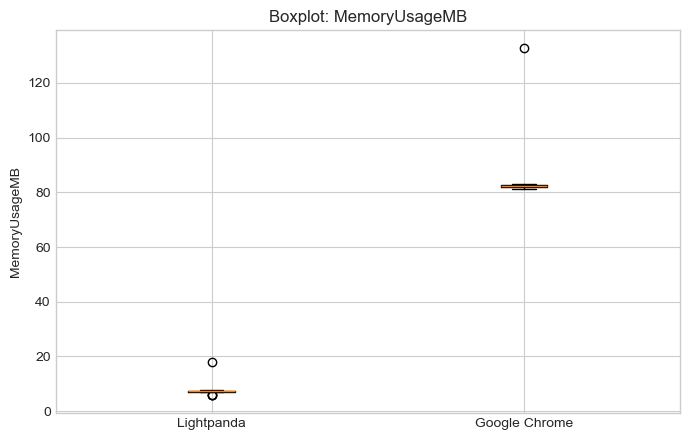

In [8]:
for metric in ['TotalTimeMs', 'MemoryUsageMB']:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    box_data = [df[df['Engine'] == e][metric].values for e in expected_engines]
    ax.boxplot(box_data, labels=expected_engines, showfliers=True)
    ax.set_title(f'Boxplot: {metric}')
    ax.set_ylabel(metric)

    plt.tight_layout()
    plt.show()

## 9. Speedup and Efficiency Analysis

Per-iteration speedups/ratios, geometric mean speedup, win-rate, and phase contribution.

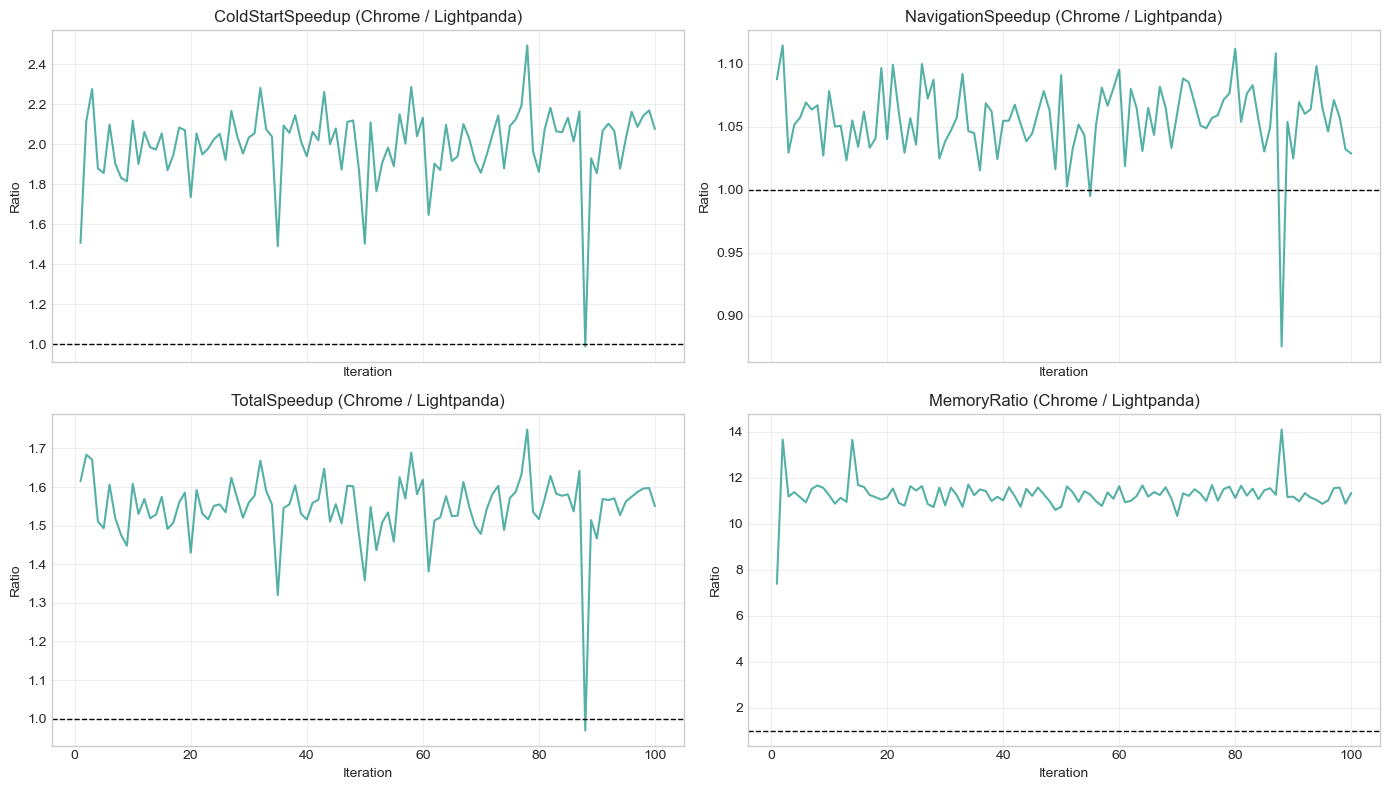

Geometric mean total speedup (Chrome/Lightpanda): 1.544x
Fraction of iterations where Lightpanda total time is lower: 99.00%


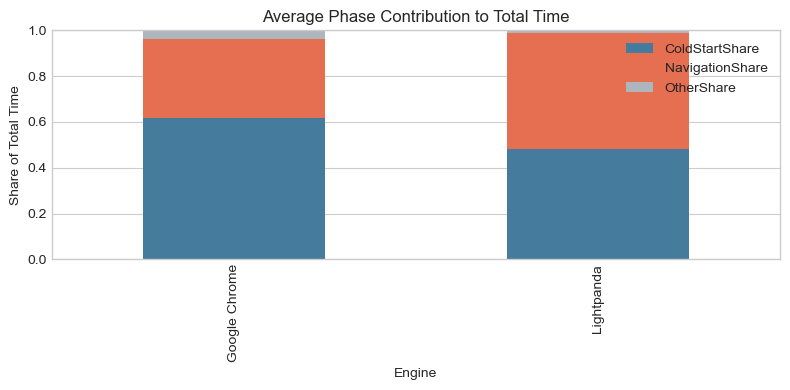

ColdStartTimeMs  NavigationTimeMs  \
Engine        Phase                                                      
Google Chrome Steady-State (11-100)          307.067           172.152   
              Warmup (1-10)                  319.364           175.857   
Lightpanda    Steady-State (11-100)          154.787           163.299   
              Warmup (1-10)                  166.052           165.166   

                                     TotalTimeMs  MemoryUsageMB  
Engine        Phase                                              
Google Chrome Steady-State (11-100)      495.873         82.187  
              Warmup (1-10)              525.502         87.240  
Lightpanda    Steady-State (11-100)      322.210          7.298  
              Warmup (1-10)              335.961          8.209

In [9]:
speedup_cols = ['ColdStartSpeedup', 'NavigationSpeedup', 'TotalSpeedup', 'MemoryRatio']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, col in zip(axes.flatten(), speedup_cols):
    ax.plot(pivot['Iteration'], pivot[col], color='#2a9d8f', alpha=0.8)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{col} (Chrome / Lightpanda)')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Ratio')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

geo_mean_speedup = float(np.exp(np.log(pivot['TotalSpeedup']).mean()))
lightpanda_win_rate = float((pivot['TotalSpeedup'] > 1).mean())

phase_contrib = df.groupby('Engine')[['ColdStartShare', 'NavigationShare']].mean().copy()
phase_contrib['OtherShare'] = 1 - phase_contrib['ColdStartShare'] - phase_contrib['NavigationShare']

print(f'Geometric mean total speedup (Chrome/Lightpanda): {geo_mean_speedup:.3f}x')
print(f'Fraction of iterations where Lightpanda total time is lower: {lightpanda_win_rate:.2%}')

phase_contrib.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#457b9d', '#e76f51', '#adb5bd'])
plt.title('Average Phase Contribution to Total Time')
plt.ylabel('Share of Total Time')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Warmup vs steady-state comparison
warmup_cutoff = 10
df['Phase'] = np.where(df['Iteration'] <= warmup_cutoff, 'Warmup (1-10)', 'Steady-State (11-100)')
warmup_summary = df.groupby(['Engine', 'Phase'])[metrics].mean().round(3)
warmup_summary

## 10. Stability Analysis (Rolling Windows and Outliers)

Rolling mean/std diagnostics and outlier detection with IQR thresholds.

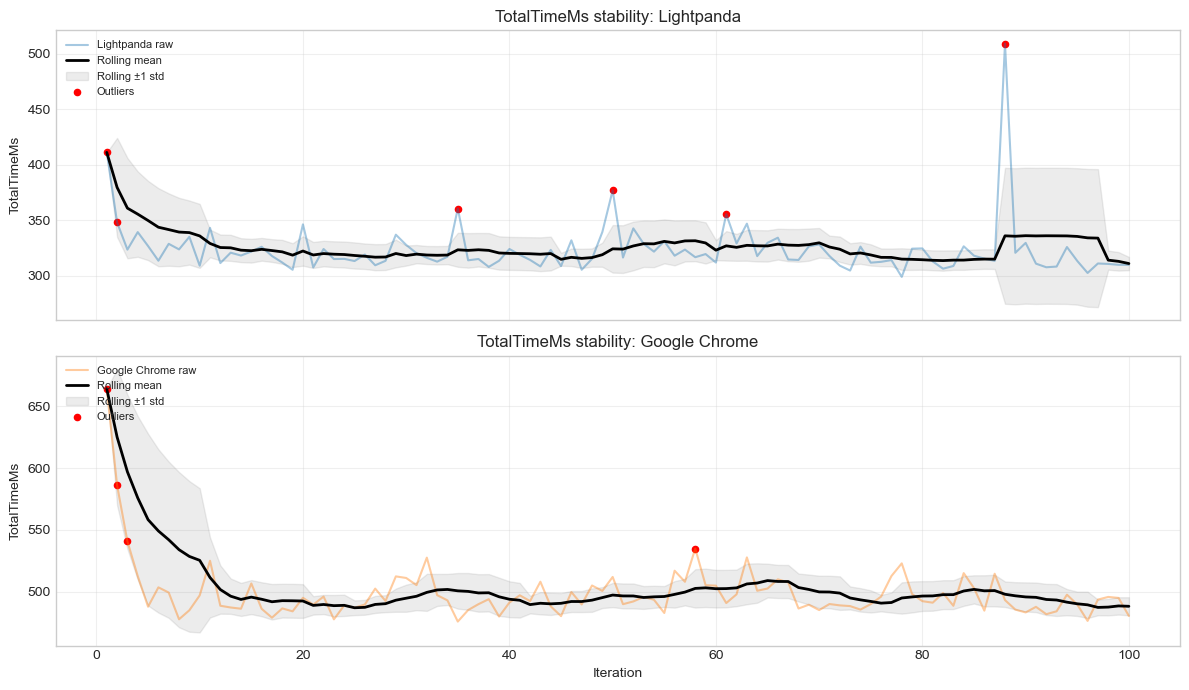

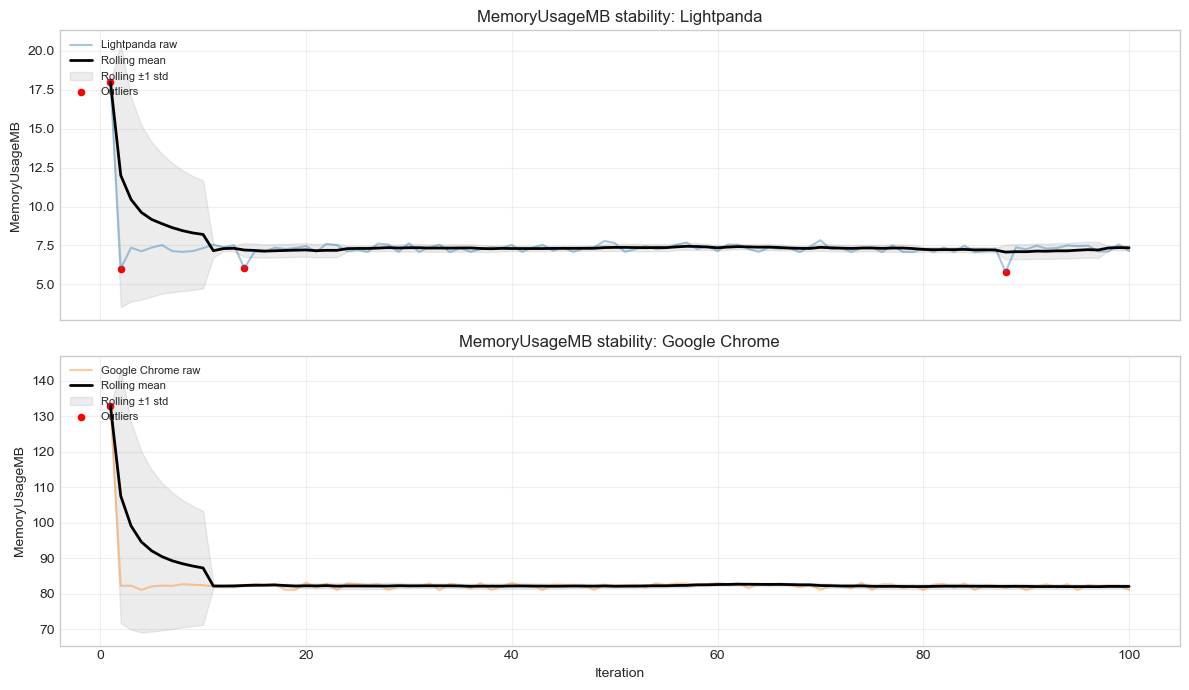

,Engine,Metric,OutlierCount
0,Lightpanda,TotalTimeMs,6
1,Google Chrome,TotalTimeMs,4
2,Lightpanda,MemoryUsageMB,4
3,Google Chrome,MemoryUsageMB,1


In [10]:
def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_tables = []
for metric in ['TotalTimeMs', 'MemoryUsageMB']:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    for i, engine in enumerate(expected_engines):
        d = df[df['Engine'] == engine].sort_values('Iteration').copy()
        d['roll_mean'] = d[metric].rolling(rolling_window, min_periods=1).mean()
        d['roll_std'] = d[metric].rolling(rolling_window, min_periods=1).std().fillna(0)
        d['is_outlier'] = iqr_outlier_mask(d[metric])

        axes[i].plot(d['Iteration'], d[metric], alpha=0.4, label=f'{engine} raw', color=colors[engine])
        axes[i].plot(d['Iteration'], d['roll_mean'], linewidth=2, label='Rolling mean', color='black')
        axes[i].fill_between(
            d['Iteration'],
            d['roll_mean'] - d['roll_std'],
            d['roll_mean'] + d['roll_std'],
            alpha=0.15,
            color='gray',
            label='Rolling ±1 std'
        )
        out_pts = d[d['is_outlier']]
        axes[i].scatter(out_pts['Iteration'], out_pts[metric], color='red', s=20, label='Outliers')
        axes[i].set_title(f'{metric} stability: {engine}')
        axes[i].set_ylabel(metric)
        axes[i].legend(loc='upper left', fontsize=8)
        axes[i].grid(True, alpha=0.3)

        outlier_tables.append({
            'Engine': engine,
            'Metric': metric,
            'OutlierCount': int(d['is_outlier'].sum())
        })

    axes[-1].set_xlabel('Iteration')
    plt.tight_layout()
    plt.show()

outlier_summary = pd.DataFrame(outlier_tables)
outlier_summary

## 11. Summary and Findings

Consolidated view of key results across all 100 isolated-launch iterations.

In [11]:
# --- derived scalars ---
mean_total_speedup   = pivot["TotalSpeedup"].mean()
median_total_speedup = pivot["TotalSpeedup"].median()
mean_memory_ratio    = pivot["MemoryRatio"].mean()
median_memory_ratio  = pivot["MemoryRatio"].median()

def _delta(metric):
    return delta_table.loc[delta_table["Metric"] == metric, "MeanDeltaPct_Chrome_vs_Lightpanda"].values[0]

total_delta      = _delta("TotalTimeMs")
nav_delta        = _delta("NavigationTimeMs")
coldstart_delta  = _delta("ColdStartTimeMs")
mem_delta        = _delta("MemoryUsageMB")

# --- findings table ---
findings_df = pd.DataFrame({
    "Metric": ["Total time", "Navigation time", "Cold-start time", "Memory usage"],
    "Chrome mean Δ% vs Lightpanda": [
        f"+{total_delta:.1f}%",
        f"+{nav_delta:.1f}%",
        f"+{coldstart_delta:.1f}%",
        f"+{mem_delta:,.0f}%",
    ],
    "Note": [
        f"Lightpanda {mean_total_speedup:.2f}x faster on average (geo mean: {geo_mean_speedup:.2f}x)",
        "Lightpanda faster in navigation phase across all iterations",
        "Lightpanda cold-start faster than Chrome (both launched fresh per iteration)",
        f"Chrome uses ~{mean_memory_ratio:.0f}x more memory on average",
    ],
})
display(findings_df)

# --- prose summary ---
print(f"""
Key Findings
============
Speed
  - Lightpanda is {geo_mean_speedup:.2f}x faster than Chrome on total request time (geometric mean, {expected_iterations} iterations).
  - Mean speedup: {mean_total_speedup:.2f}x  |  Median speedup: {median_total_speedup:.2f}x
  - Lightpanda wins on total time in {lightpanda_win_rate:.0%} of iterations.

Phase breakdown
  - Cold-start phase : Lightpanda ~{coldstart_delta:.0f}% faster than Chrome (both launched fresh per iteration).
  - Navigation phase : Lightpanda ~{nav_delta:.0f}% faster than Chrome.

Memory
  - Chrome uses ~{mean_memory_ratio:.0f}x more memory than Lightpanda (mean ratio across all iterations).
  - Median memory ratio: {median_memory_ratio:.0f}x.
""")

,Metric,Chrome mean Δ% vs Lightpanda,Note
0,Total time,+54.2%,Lightpanda 1.55x faster on average (geo mean: ...
1,Navigation time,+5.5%,Lightpanda faster in navigation phase across a...
2,Cold-start time,+97.7%,Lightpanda cold-start faster than Chrome (both...
3,Memory usage,"+1,019%",Chrome uses ~11x more memory on average



Key Findings
Speed
  - Lightpanda is 1.54x faster than Chrome on total request time (geometric mean, 100 iterations).
  - Mean speedup: 1.55x  |  Median speedup: 1.56x
  - Lightpanda wins on total time in 99% of iterations.

Phase breakdown
  - Cold-start phase : Lightpanda ~98% faster than Chrome (both launched fresh per iteration).
  - Navigation phase : Lightpanda ~6% faster than Chrome.

Memory
  - Chrome uses ~11x more memory than Lightpanda (mean ratio across all iterations).
  - Median memory ratio: 11x.

